## Energy loss and momentum broadening in cold QCD matter

## Import and Preprocess

In [1]:

# -*- coding: utf-8 -*-
from __future__ import annotations
import re, math, logging
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple
import numpy as np, pandas as pd

def make_logger(name: str = "eloss", level: int = logging.INFO) -> logging.Logger:
    logger = logging.getLogger(name)
    if not logger.handlers:
        logger.setLevel(level)
        h = logging.StreamHandler()
        h.setLevel(level)
        h.setFormatter(logging.Formatter("[%(levelname)s] %(message)s"))
        logger.addHandler(h)
    else:
        logger.setLevel(level)
        for h in logger.handlers:
            h.setLevel(level)
    return logger
log = make_logger()

def _read_table_auto(path: Path, logger: logging.Logger = log) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    tries = [
        dict(sep="\t", header=None, comment="#"),
        dict(sep="\t", header=0, comment="#"),
        dict(sep=",", header=None, comment="#"),
        dict(sep=",", header=0, comment="#"),
        dict(delim_whitespace=True, header=None, comment="#"),
        dict(delim_whitespace=True, header=0, comment="#"),
    ]
    last = None
    for kw in tries:
        try:
            df = pd.read_csv(path, **kw)
            df = df.dropna(axis=1, how="all")
            if df.shape[1] < 3: 
                continue
            for c in df.columns:
                df[c] = pd.to_numeric(df[c], errors="coerce")
            if df.iloc[:, :3].isna().any().any():
                continue
            return df
        except Exception as e:
            last = e
    if last:
        logger.error(f"Failed to parse {path}: {last}")
    raise RuntimeError(f"Could not parse table: {path}")

def _unique_sorted(a: Iterable[float]) -> np.ndarray:
    A = np.array(list(a), dtype=float)
    A = np.unique(A[~np.isnan(A)]); A.sort()
    return A

class BilinearRectGrid:
    def __init__(self, x: np.ndarray, y: np.ndarray, Z: np.ndarray):
        if Z.shape != (x.size, y.size): 
            raise ValueError("Z shape must be (len(x), len(y))")
        if not (np.all(np.diff(x) > 0) and np.all(np.diff(y) > 0)):
            raise ValueError("Grid coords must be strictly increasing.")
        self.x, self.y, self.Z = x, y, Z
    def _idx(self, arr, v):
        i = np.searchsorted(arr, v) - 1
        return 0 if i < 0 else (arr.size-2 if i >= arr.size-1 else int(i))
    def __call__(self, xq: float, yq: float) -> float:
        i = self._idx(self.x, float(xq)); j = self._idx(self.y, float(yq))
        x0,x1 = self.x[i], self.x[i+1]; y0,y1 = self.y[j], self.y[j+1]
        dx = x1-x0 if x1!=x0 else 1e-12; dy = y1-y0 if y1!=y0 else 1e-12
        tx = (min(max(xq,x0),x1)-x0)/dx; ty = (min(max(yq,y0),y1)-y0)/dy
        Z = self.Z
        return float(Z[i,j]*(1-tx)*(1-ty) + Z[i+1,j]*tx*(1-ty) + Z[i,j+1]*(1-tx)*ty + Z[i+1,j+1]*tx*ty)

@dataclass
class Grid2D:
    y_vals: np.ndarray
    pt_vals: np.ndarray
    Z: np.ndarray
    def bilinear(self) -> BilinearRectGrid:
        return BilinearRectGrid(self.y_vals, self.pt_vals, self.Z)

def _build_rect_grid(df: pd.DataFrame, value_col_index: int) -> Grid2D:
    y = df.iloc[:,0].to_numpy(float); pt = df.iloc[:,1].to_numpy(float); val = df.iloc[:,value_col_index].to_numpy(float)
    ys = _unique_sorted(y); pts = _unique_sorted(pt)
    Z = np.full((ys.size, pts.size), np.nan, float)
    ymap = {v:i for i,v in enumerate(ys)}; pmap = {v:j for j,v in enumerate(pts)}
    for yi,pi,vi in zip(y,pt,val):
        if not (np.isnan(yi) or np.isnan(pi) or np.isnan(vi)):
            Z[ymap[yi], pmap[pi]] = vi
    if np.isnan(Z).any():
        miss = np.isnan(Z).mean()*100.0
        raise ValueError(f"Input does not form a complete rect grid (≈{miss:.1f}% missing)." )
    return Grid2D(ys, pts, Z)

@dataclass
class CentBin:
    tag: str
    pA_log: Grid2D
    pp_log: Grid2D
    rpa: Grid2D
    rpa_err: Optional[Grid2D] = None
    @property
    def y_range(self): return float(self.rpa.y_vals.min()), float(self.rpa.y_vals.max())
    @property
    def pt_range(self): return float(self.rpa.pt_vals.min()), float(self.rpa.pt_vals.max())
    def pA(self, y, pt): return math.exp(self.pA_log.bilinear()(y, pt))
    def pp(self, y, pt): return math.exp(self.pp_log.bilinear()(y, pt))
    def RpA(self, y, pt): return float(self.rpa.bilinear()(y, pt))
    def RpAerr(self, y, pt): return 0.0 if self.rpa_err is None else float(self.rpa_err.bilinear()(y, pt))

class ELossRun:
    def __init__(self, base_dir: Path, particle: Optional[str] = None, logger: logging.Logger = log, quad_n_y: int = 32, quad_n_pt: int = 64):
        self.base_dir = Path(base_dir); self.logger = logger; self.particle = particle; self.energy=None; self.cent_bins = {}
        self.quad_n_y=int(quad_n_y); self.quad_n_pt=int(quad_n_pt)
        self._discover_and_load()
    def _discover_and_load(self):
        files = list(self.base_dir.glob("cent_*_*_*.*")) or list(self.base_dir.glob("cent_*_*.*"))
        if not files: raise RuntimeError(f"No files matching 'cent_*' in {self.base_dir}")
        if self.particle is None:
            for f in files:
                m = re.search(r"cent_[0-9]+-[0-9]+_([A-Za-z0-9]+)_", f.name)
                if m: self.particle=m.group(1); break
            if self.particle is None: self.particle = "Unknown"
        for part in self.base_dir.parts:
            if "TeV" in part: self.energy = part
        groups = {}
        for f in files:
            m = re.search(r"cent_([0-9]+-[0-9]+)", f.name)
            if not m: continue
            tag = m.group(1); groups.setdefault(tag, {})
            if "pA-cross-section" in f.name: groups[tag]["pA"]=f
            elif "pp-cross-section" in f.name: groups[tag]["pp"]=f
            elif "_RpA" in f.name: groups[tag]["RpA"]=f
        for tag,b in sorted(groups.items(), key=lambda kv: (int(kv[0].split("-")[0]), int(kv[0].split("-")[1]))):
            miss=[k for k in ("pA","pp","RpA") if k not in b]
            if miss: 
                self.logger.warning(f"[{tag}] skip missing {miss}"); 
                continue
            try:
                self.cent_bins[tag] = self._load_cent_bin(tag, b["pA"], b["pp"], b["RpA"])
                self.logger.info(f"Loaded {tag}")
            except Exception as e:
                self.logger.error(f"Failed to load {tag}: {e}")
        if not self.cent_bins: raise RuntimeError("Found no complete centrality triplets.")
    def _load_cent_bin(self, tag, pA_path, pp_path, rpa_path):
        df_pA=_read_table_auto(Path(pA_path), logger=self.logger); df_pp=_read_table_auto(Path(pp_path), logger=self.logger); df_rp=_read_table_auto(Path(rpa_path), logger=self.logger)
        pA_log=_build_rect_grid(df_pA.iloc[:,:4],2); pA_log.Z=np.log(np.clip(pA_log.Z,1e-300,np.inf))
        pp_log=_build_rect_grid(df_pp.iloc[:,:4],2); pp_log.Z=np.log(np.clip(pp_log.Z,1e-300,np.inf))
        rpa=_build_rect_grid(df_rp.iloc[:,:4],2); rpa_err=None
        if df_rp.shape[1]>=4: rpa_err=_build_rect_grid(df_rp.iloc[:,:4],3)
        return CentBin(tag, pA_log, pp_log, rpa, rpa_err)
    @staticmethod
    def _gauss_legendre_nodes(a,b,n):
        x,w=np.polynomial.legendre.leggauss(n); t=0.5*(b-a); m=0.5*(b+a); return (m+t*x),(t*w)
    def _weight_pt(self, cent: CentBin, pt: float) -> float:
        y0=0.0; y_min,y_max=cent.y_range; yq=float(np.clip(y0,y_min,y_max)); return max(1e-300, cent.pA(yq, float(pt))*float(pt))
    def mean_rpa_over_y(self, cent_tag, y_range, pt_range):
        cent=self.cent_bins[cent_tag]
        y1,y2=max(min(y_range),cent.y_range[0]), min(max(y_range),cent.y_range[1])
        p1,p2=max(min(pt_range),cent.pt_range[0]), min(max(pt_range),cent.pt_range[1])
        pts,wpt=self._gauss_legendre_nodes(p1,p2,self.quad_n_pt)
        denom=float(np.sum([self._weight_pt(cent,p)*wp for p,wp in zip(pts,wpt)]))
        def g(y): return float(np.sum([cent.RpA(y,p)*self._weight_pt(cent,p)*wp for p,wp in zip(pts,wpt)])/denom)
        ys,wys=self._gauss_legendre_nodes(y1,y2,self.quad_n_y)
        return float(np.sum([g(y)*wy for y,wy in zip(ys,wys)])/(y2-y1))
    def mean_rpa_over_pt(self, cent_tag, y_range, pt_range):
        cent=self.cent_bins[cent_tag]
        y1,y2=max(min(y_range),cent.y_range[0]), min(max(y_range),cent.y_range[1])
        p1,p2=max(min(pt_range),cent.pt_range[0]), min(max(pt_range),cent.pt_range[1])
        ys,wys=self._gauss_legendre_nodes(y1,y2,self.quad_n_y)
        def rpy(pt): return float(np.sum([cent.RpA(y,pt)*wy for y,wy in zip(ys,wys)])/(y2-y1))
        pts,wpt=self._gauss_legendre_nodes(p1,p2,self.quad_n_pt)
        num=float(np.sum([rpy(p)*self._weight_pt(cent,p)*wp for p,wp in zip(pts,wpt)]))
        denom=float(np.sum([self._weight_pt(cent,p)*wp for p,wp in zip(pts,wpt)]))
        return num/denom
    def mean_rpa_over_y_and_pt(self, cent_tag, y_range, pt_range):
        cent=self.cent_bins[cent_tag]
        y1,y2=max(min(y_range),cent.y_range[0]), min(max(y_range),cent.y_range[1])
        p1,p2=max(min(pt_range),cent.pt_range[0]), min(max(pt_range),cent.pt_range[1])
        pts,wpt=self._gauss_legendre_nodes(p1,p2,self.quad_n_pt); ys,wys=self._gauss_legendre_nodes(y1,y2,self.quad_n_y)
        denom=float(np.sum([self._weight_pt(cent,p)*wp for p,wp in zip(pts,wpt)])*(y2-y1))
        acc=0.0
        for p,wp in zip(pts,wpt):
            for y,wy in zip(ys,wys):
                acc += cent.RpA(y,p)*self._weight_pt(cent,p)*wp*wy
        return acc/denom
    def mean_rpa_err_over_y_and_pt(self, cent_tag, y_range, pt_range):
        cent=self.cent_bins[cent_tag]
        if cent.rpa_err is None: return 0.0
        y1,y2=max(min(y_range),cent.y_range[0]), min(max(y_range),cent.y_range[1])
        p1,p2=max(min(pt_range),cent.pt_range[0]), min(max(pt_range),cent.pt_range[1])
        pts,wpt=self._gauss_legendre_nodes(p1,p2,self.quad_n_pt); ys,wys=self._gauss_legendre_nodes(y1,y2,self.quad_n_y)
        denom=float(np.sum([self._weight_pt(cent,p)*wp for p,wp in zip(pts,wpt)])*(y2-y1))
        acc=0.0
        for p,wp in zip(pts,wpt):
            for y,wy in zip(ys,wys):
                e=cent.RpAerr(y,p); acc += (e*e)*self._weight_pt(cent,p)*wp*wy
        return math.sqrt(acc/denom)
    def rpa_vs_centrality(self, y_range=(-5.0,5.0), pt_range=(0.1,20.0)):
        rows=[]
        for tag in sorted(self.cent_bins.keys(), key=lambda t: (int(t.split("-")[0]), int(t.split("-")[1]))):
            L,R=[float(x) for x in tag.split("-")]; mid=0.5*(L+R); dx=0.5*(R-L)
            try:
                val=self.mean_rpa_over_y_and_pt(tag,y_range,pt_range); err=self.mean_rpa_err_over_y_and_pt(tag,y_range,pt_range)
                rows.append(dict(cent_tag=tag, cent_mid=mid, xerr=dx, cent_left=L, cent_right=R, RpA=val, dRpA=err))
            except Exception as e:
                self.logger.error(f"Average failed for {tag}: {e}")
        return pd.DataFrame(rows).sort_values("cent_mid").reset_index(drop=True)

    def rpa_vs_y(self, cent_tag, y_edges, pt_range=(0.1,20.0)):
        y_edges=np.asarray(list(y_edges), float); rows=[]
        for yl,yr in zip(y_edges[:-1], y_edges[1:]):
            try:
                rows.append(dict(y_left=yl, y_right=yr, y_mid=0.5*(yl+yr), RpA=self.mean_rpa_over_y(cent_tag, (yl,yr), pt_range)))
            except Exception as e:
                self.logger.error(f"rpa_vs_y {cent_tag} [{yl},{yr}] failed: {e}")
        return pd.DataFrame(rows)
    def rpa_vs_pt(self, cent_tag, y_range, pt_edges):
        pt_edges=np.asarray(list(pt_edges), float); rows=[]
        for pl,pr in zip(pt_edges[:-1], pt_edges[1:]):
            try:
                rows.append(dict(pt_left=pl, pt_right=pr, pt_mid=0.5*(pl+pr), RpA=self.mean_rpa_over_pt(cent_tag, y_range, (pl,pr))))
            except Exception as e:
                self.logger.error(f"rpa_vs_pt {cent_tag} [{pl},{pr}] failed: {e}")
        return pd.DataFrame(rows)

def load_eloss_run(base_dir: str, particle: Optional[str] = None, log_level: int = logging.INFO, quad_n_y: int = 32, quad_n_pt: int = 64) -> ELossRun:
    logger = make_logger(level=log_level)
    return ELossRun(Path(base_dir), particle=particle, logger=logger, quad_n_y=quad_n_y, quad_n_pt=quad_n_pt)

def _init_ax(ax=None, xlabel=None, ylabel=None, title=None):
    import matplotlib.pyplot as plt
    if ax is None: fig, ax = plt.subplots(figsize=(6,4))
    else: fig = ax.figure
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if title:  ax.set_title(title)
    ax.grid(True, ls="--", alpha=0.4)
    return fig, ax

def plot_rpa_vs_centrality(run: ELossRun, y_range=(-5,5), pt_range=(0.1,20.0), show_yerr=True, ax=None):
    import matplotlib.pyplot as plt
    df = run.rpa_vs_centrality(y_range=y_range, pt_range=pt_range)
    yerr = df["dRpA"].values if (show_yerr and "dRpA" in df) else None
    xerr = df["xerr"].values
    fig, ax = _init_ax(ax, "Centrality [%]", "RpA", f"RpA vs Centrality ({run.particle} @ {run.energy or ''})")
    ax.errorbar(df["cent_mid"], df["RpA"], xerr=xerr, yerr=yerr, fmt="o", capsize=3)
    ax.set_xlim(-2, 102)
    return fig, ax, df

def plot_rpa_vs_y_grid(run: ELossRun, cent_tags: Optional[List[str]] = None, y_edges=None, pt_range=(0.1,20.0), ncols=2, figsize=(10,8)):
    import matplotlib.pyplot as plt, numpy as np
    if cent_tags is None:
        cent_tags = sorted(run.cent_bins.keys(), key=lambda t: (int(t.split("-")[0]), int(t.split("-")[1])))
    if y_edges is None:
        y_edges = np.linspace(-5, 5, 21)
    n=len(cent_tags); nrows=(n+ncols-1)//ncols; fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False); axes=axes.ravel()
    for i, tag in enumerate(cent_tags):
        df = run.rpa_vs_y(tag, y_edges=y_edges, pt_range=pt_range)
        _, ax = _init_ax(axes[i], "y", "RpA", f"{tag}%")
        axes[i].step(df["y_right"], df["RpA"], where="post")
    for j in range(i+1, axes.size): axes[j].set_visible(False)
    fig.tight_layout(); return fig, axes[:n]

def plot_rpa_vs_pt_grid(run: ELossRun, y_range, cent_tags: Optional[List[str]] = None, pt_edges=None, ncols=2, figsize=(10,8)):
    import matplotlib.pyplot as plt, numpy as np
    if cent_tags is None:
        cent_tags = sorted(run.cent_bins.keys(), key=lambda t: (int(t.split("-")[0]), int(t.split("-")[1])))
    if pt_edges is None:
        pt_edges = np.arange(0.0, 20.0+2.5, 2.5)
    n=len(cent_tags); nrows=(n+ncols-1)//ncols; fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False); axes=axes.ravel()
    for i, tag in enumerate(cent_tags):
        df = run.rpa_vs_pt(tag, y_range=y_range, pt_edges=pt_edges)
        _, ax = _init_ax(axes[i], "pT [GeV]", "RpA", f"{tag}%  {y_range[0]}<y<{y_range[1]}")
        axes[i].step(df["pt_right"], df["RpA"], where="post")
    for j in range(i+1, axes.size): axes[j].set_visible(False)
    fig.tight_layout(); return fig, axes[:n]

In [2]:
import os, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Point to the folder that has files like:
#   cent_0-20_JPsi_pA-cross-section.tsv
#   cent_0-20_JPsi_pp-cross-section.tsv
#   cent_0-20_JPsi_RpA.tsv
# (and similarly for 20-40, 40-60, 60-100)
BASE = "/home/sawin/Desktop/Charmonia/quenching_integration/output/JPsi"  # <- change to your real data folder if needed

run = load_eloss_run(BASE, particle="JPsi", log_level=logging.INFO)
print(f"Loaded {len(run.cent_bins)} centrality bins for particle={run.particle}, energy={run.energy}")
print("Centralities:", list(run.cent_bins.keys()))

[INFO] Loaded 0-10
[INFO] Loaded 10-20
[INFO] Loaded 20-30
[INFO] Loaded 30-40
[INFO] Loaded 40-50
[INFO] Loaded 50-60
[INFO] Loaded 60-70
[INFO] Loaded 70-100


Loaded 8 centrality bins for particle=JPsi, energy=None
Centralities: ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-100']


## $R_{pA}$ vs Centrality

In [3]:

# Choose y and pT ranges; they will be clamped to the available grid extents
y_range = (-5.0, 5.0)
pt_range = (0.1, 20.0)

df_cent = run.rpa_vs_centrality(y_range=y_range, pt_range=pt_range)
df_cent

,cent_tag,cent_mid,xerr,cent_left,cent_right,RpA,dRpA
0,0-10,5.0,5.0,0.0,10.0,0.799772,0.000015
1,10-20,15.0,5.0,10.0,20.0,0.785531,0.000016
2,20-30,25.0,5.0,20.0,30.0,0.782031,0.000015
3,30-40,35.0,5.0,30.0,40.0,0.782849,0.000016
4,40-50,45.0,5.0,40.0,50.0,0.788658,0.000017
5,50-60,55.0,5.0,50.0,60.0,0.803022,0.000016
6,60-70,65.0,5.0,60.0,70.0,0.834935,0.000017
7,70-100,85.0,15.0,70.0,100.0,0.766756,0.000012


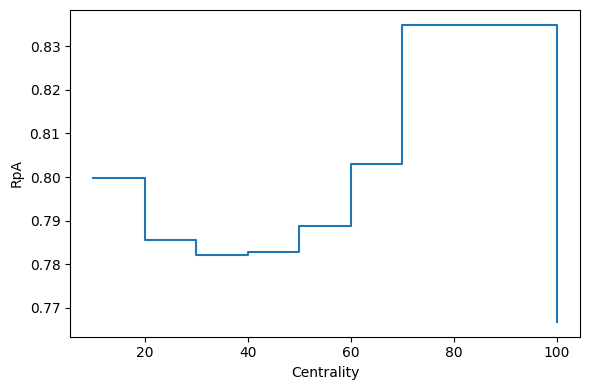

In [4]:
plt.figure(figsize=(6,4))
plt.step(df_cent["cent_right"], df_cent["RpA"], where="post")
plt.xlabel("Centrality")
plt.ylabel("RpA")
plt.tight_layout()
plt.show()

In [5]:
# Save
# out_csv = os.path.join(BASE, "rpa_vs_centrality.csv")
# df_cent.to_csv(out_csv, index=False)
# print("Saved:", out_csv)

## $R_{pA}$ vs Rapidity

In [6]:
# Pick a centrality that exists in your files (e.g., '40-60' or '20-40')
cent_tag = sorted(run.cent_bins.keys())[0]
y_edges = np.linspace(-5, 5, 21)  # 0.5-wide bins
pt_range = (0.1, 20.0)

df_y = run.rpa_vs_y(cent_tag, y_edges=y_edges, pt_range=pt_range)
df_y

,y_left,y_right,y_mid,RpA
0,-5.0,-4.5,-4.75,1.031169
1,-4.5,-4.0,-4.25,0.930903
2,-4.0,-3.5,-3.75,0.879198
3,-3.5,-3.0,-3.25,0.847728
4,-3.0,-2.5,-2.75,0.824244
5,-2.5,-2.0,-2.25,0.805609
6,-2.0,-1.5,-1.75,0.791243
7,-1.5,-1.0,-1.25,0.779468
8,-1.0,-0.5,-0.75,0.769102
9,-0.5,0.0,-0.25,0.759700


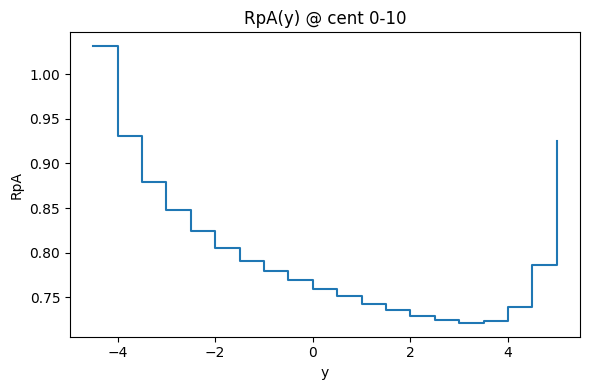

In [7]:
# Plot (single figure, as requested)
plt.figure(figsize=(6,4))
plt.step(df_y["y_right"], df_y["RpA"], where="post")
plt.xlabel("y")
plt.ylabel("RpA")
plt.title(f"RpA(y) @ cent {cent_tag}")
plt.tight_layout()
plt.show()

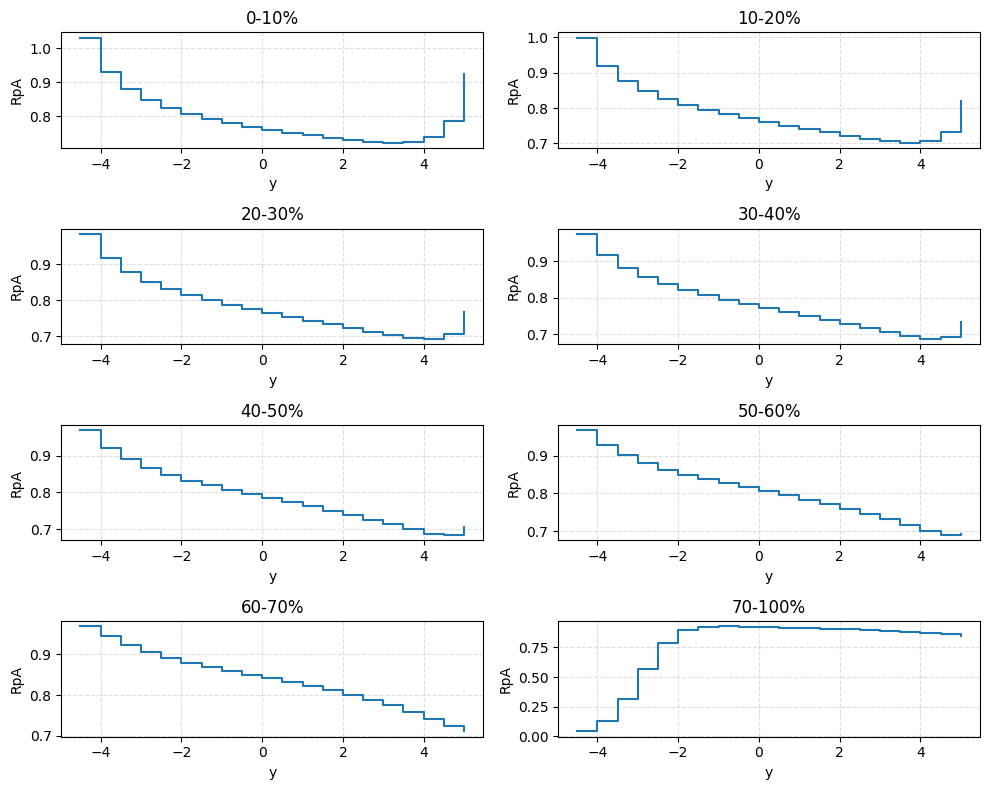

In [8]:
# 2) RpA vs y (pT-averaged) subplots across centralities
import numpy as np
y_edges = np.linspace(-5, 5, 21)
figY, _ = plot_rpa_vs_y_grid(run, y_edges=y_edges, pt_range=(0.1,20.0), ncols=2, figsize=(10,8))
# figY.savefig("RpA_vs_y_grid_5TeV.png", dpi=200)

## $R_{pA}$ vs Transverse Momentum

In [9]:
# Example: forward rapidity (1.5 < y < 4.0); change as needed
y_range = (1.5, 4.0)
pt_edges = np.arange(0.0, 20.0+2.5, 2.5)

df_pt = run.rpa_vs_pt(cent_tag, y_range=y_range, pt_edges=pt_edges)
df_pt

,pt_left,pt_right,pt_mid,RpA
0,0.0,2.5,1.25,0.277507
1,2.5,5.0,3.75,0.840497
2,5.0,7.5,6.25,1.194962
3,7.5,10.0,8.75,1.146558
4,10.0,12.5,11.25,1.064050
5,12.5,15.0,13.75,1.010439
6,15.0,17.5,16.25,0.978074
7,17.5,20.0,18.75,0.958146


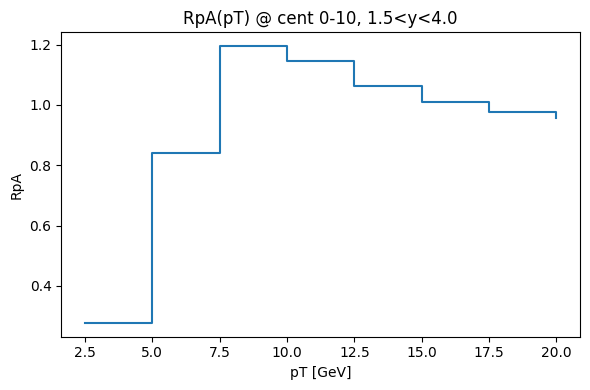

In [10]:
plt.figure(figsize=(6,4))
plt.step(df_pt["pt_right"], df_pt["RpA"], where="post")
plt.xlabel("pT [GeV]")
plt.ylabel("RpA")
plt.title(f"RpA(pT) @ cent {cent_tag}, {y_range[0]}<y<{y_range[1]}")
plt.tight_layout()
plt.show()

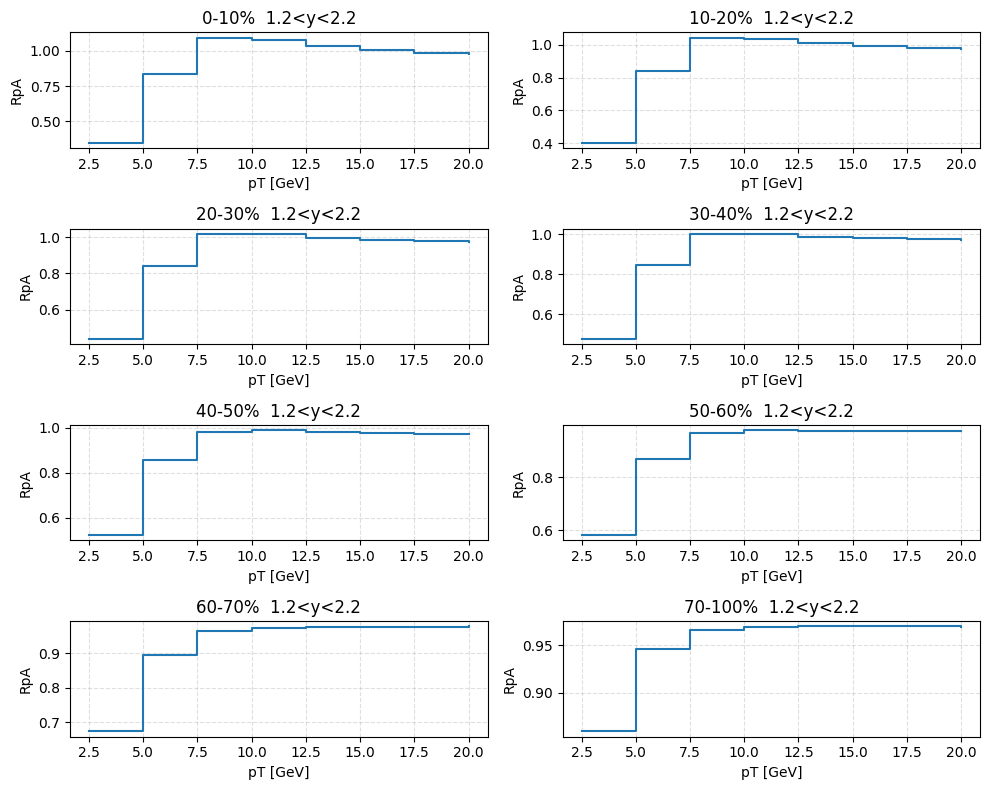

In [15]:
# 3) RpA vs pT (y-averaged) subplots across centralities
pt_edges = np.arange(0.0, 20.0+2.5, 2.5)

# forward / mid / backward windows you used
figPT_fwd, _ = plot_rpa_vs_pt_grid(run, y_range=(1.2,2.2),   pt_edges=pt_edges, ncols=2, figsize=(10,8))

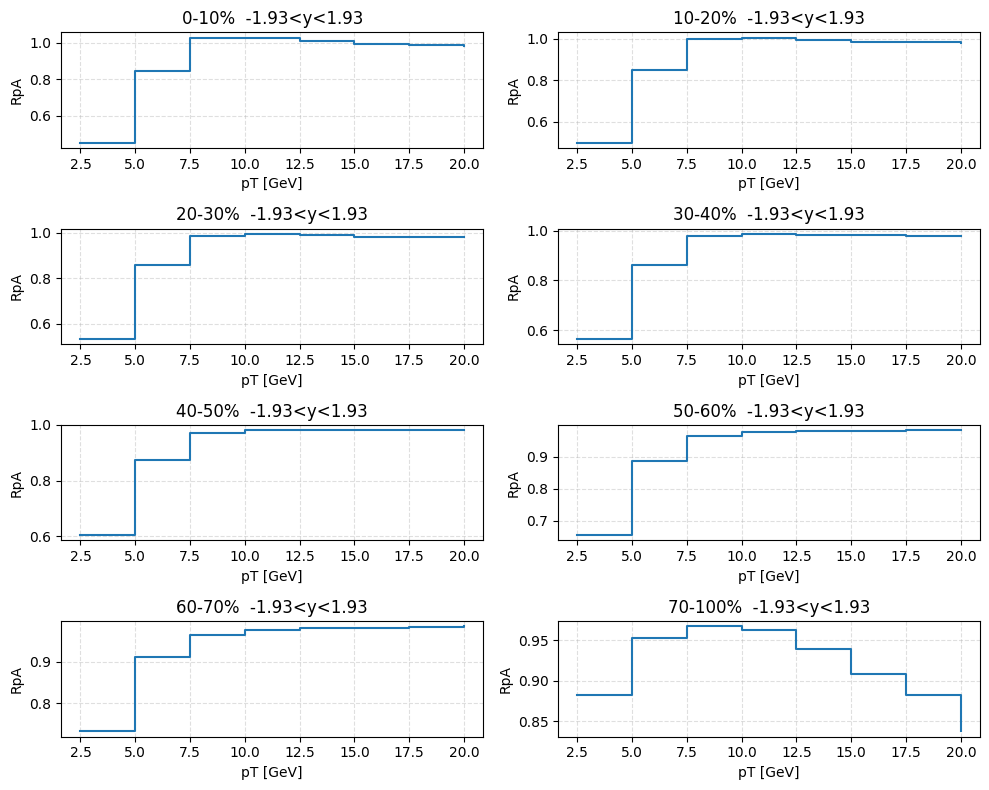

In [12]:
figPT_mid, _ = plot_rpa_vs_pt_grid(run, y_range=(-1.93,1.93), pt_edges=pt_edges, ncols=2, figsize=(10,8))

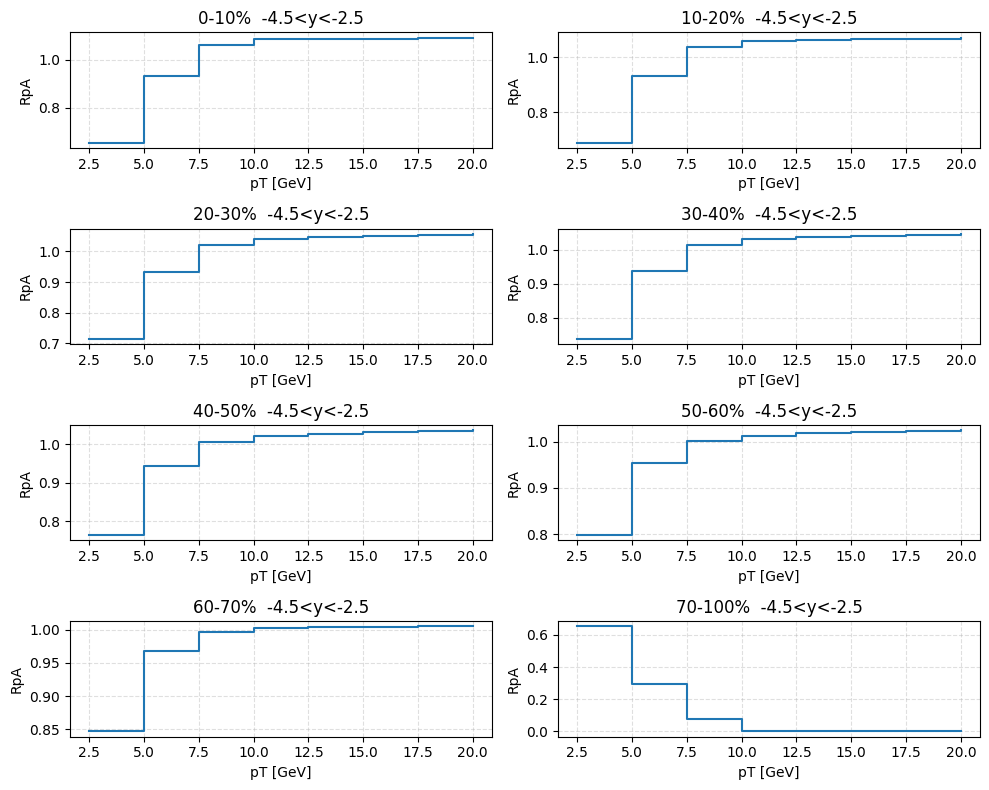

In [13]:
figPT_bwd, _ = plot_rpa_vs_pt_grid(run, y_range=(-4.5,-2.5), pt_edges=pt_edges, ncols=2, figsize=(10,8))

In [14]:
# figPT_fwd.savefig("RpA_vs_pT_forward_5TeV.png", dpi=200)
# figPT_mid.savefig("RpA_vs_pT_mid_5TeV.png", dpi=200)
# figPT_bwd.savefig("RpA_vs_pT_backward_5TeV.png", dpi=200)